# ch295 — Neural Network Math Review

*(Synthesizes: gradient descent ch213, chain rule ch216, matrix multiply ch154, sigmoid ch063, softmax+cross-entropy ch294)*

## 1. What a Neural Network Is Mathematically

A neural network is a composition of parametric functions:
$$f(x; \theta) = f_L(f_{L-1}(\ldots f_1(x; \theta_1) \ldots; \theta_{L-1}); \theta_L)$$

Each layer $f_l$ applies an affine transformation followed by a non-linear activation:
$$f_l(h; W_l, b_l) = \sigma(W_l h + b_l)$$

Training finds $\theta = \{W_l, b_l\}$ that minimizes a loss function $\mathcal{L}(f(x;\theta), y)$ via gradient descent on the gradient computed by backpropagation.

---

## 2. Forward Pass

XOR predictions: [0 1 1 0] | True: [0 1 1 0]
Accuracy: 1.0


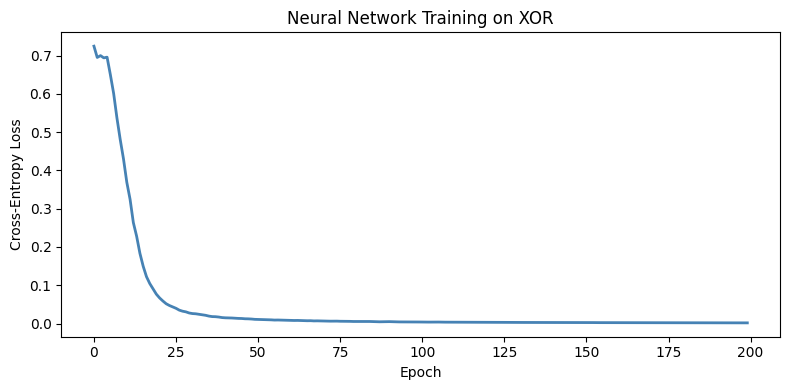

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def relu(z): return np.maximum(0, z)
def relu_grad(z): return (z > 0).astype(float)

def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))
def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(Z):
    Z_s = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z_s)
    return e / e.sum(axis=1, keepdims=True)


class NeuralNetworkFromScratch:
    """
    Fully-connected neural network: [input -> hidden1 -> hidden2 -> output]
    Trained with mini-batch SGD and backpropagation.
    """

    def __init__(self, layer_sizes, lr=0.01, rng=None):
        self.rng = rng or np.random.default_rng()
        self.lr = lr
        self.params = self._init_params(layer_sizes)

    def _init_params(self, sizes):
        # He initialization for ReLU layers
        params = []
        for i in range(len(sizes) - 1):
            fan_in = sizes[i]
            W = self.rng.normal(0, np.sqrt(2 / fan_in), (sizes[i], sizes[i+1]))
            b = np.zeros(sizes[i+1])
            params.append({'W': W, 'b': b})
        return params

    def forward(self, X):
        """Return list of (z, a) for each layer."""
        cache = []
        a = X
        for i, p in enumerate(self.params[:-1]):  # hidden layers: ReLU
            z = a @ p['W'] + p['b']
            a = relu(z)
            cache.append({'z': z, 'a': a})
        # Output layer: softmax
        p = self.params[-1]
        z = a @ p['W'] + p['b']
        a = softmax(z)
        cache.append({'z': z, 'a': a})
        return cache

    def loss(self, y_pred, y_true_onehot):
        eps = 1e-15
        return -np.mean(np.sum(y_true_onehot * np.log(np.clip(y_pred, eps, 1)), axis=1))

    def backward(self, X, cache, y_true_onehot):
        """Backpropagation: compute gradients for all parameters."""
        n = len(X)
        grads = [None] * len(self.params)

        # Output layer gradient: d(CE)/d(z_L) = softmax - y (for softmax + CE)
        dz = cache[-1]['a'] - y_true_onehot  # (n, K)

        # Activation of previous layer (or input)
        a_prev = cache[-2]['a'] if len(cache) > 1 else X

        grads[-1] = {
            'dW': a_prev.T @ dz / n,
            'db': dz.mean(axis=0),
        }

        # Propagate backward through hidden layers
        da = dz @ self.params[-1]['W'].T
        for i in range(len(self.params) - 2, -1, -1):
            dz = da * relu_grad(cache[i]['z'])
            a_prev = cache[i-1]['a'] if i > 0 else X
            grads[i] = {
                'dW': a_prev.T @ dz / n,
                'db': dz.mean(axis=0),
            }
            da = dz @ self.params[i]['W'].T

        return grads

    def update(self, grads):
        for p, g in zip(self.params, grads):
            p['W'] -= self.lr * g['dW']
            p['b'] -= self.lr * g['db']

    def fit(self, X, y_onehot, n_epochs=200, batch_size=64):
        losses = []
        n = len(X)
        for epoch in range(n_epochs):
            idx = self.rng.permutation(n)
            epoch_loss = []
            for start in range(0, n, batch_size):
                batch = idx[start:start+batch_size]
                Xb, yb = X[batch], y_onehot[batch]
                cache = self.forward(Xb)
                loss  = self.loss(cache[-1]['a'], yb)
                grads = self.backward(Xb, cache, yb)
                self.update(grads)
                epoch_loss.append(loss)
            losses.append(np.mean(epoch_loss))
        return losses

    def predict(self, X):
        return np.argmax(self.forward(X)[-1]['a'], axis=1)


# Test on XOR (not linearly separable)
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
y_xor_oh = np.eye(2)[y_xor]

nn = NeuralNetworkFromScratch([2, 4, 2], lr=0.5, rng=rng)
losses = nn.fit(np.tile(X_xor, (100,1)), np.tile(y_xor_oh, (100,1)), n_epochs=200)
preds = nn.predict(X_xor)

print('XOR predictions:', preds, '| True:', y_xor)
print('Accuracy:', (preds == y_xor).mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='steelblue', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Neural Network Training on XOR')
plt.tight_layout()
plt.show()

## 3. Backpropagation as Chain Rule

Backpropagation is the chain rule *(introduced in ch216)* applied systematically through the computation graph.

For a network with loss $\mathcal{L}$, layer $l$ output $h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)})$:

$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial h^{(l)}} \cdot \frac{\partial h^{(l)}}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial W^{(l)}}$$

The **gradient flows backward** through the network. Each layer computes its local gradient and multiplies by the upstream gradient.

Digits accuracy (train): 0.9800


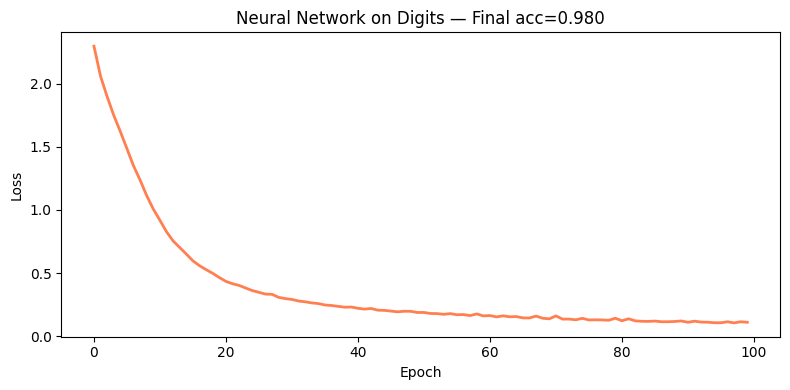

In [2]:
# Visualize gradient magnitudes across layers during training
from sklearn.datasets import load_digits
from sklearn.preprocessing import OneHotEncoder

digits = load_digits()
X_d = digits.data / 16.0  # scale to [0,1]
y_d = digits.target
ohe = OneHotEncoder(sparse_output=False)
y_d_oh = ohe.fit_transform(y_d.reshape(-1, 1))

nn_digits = NeuralNetworkFromScratch([64, 128, 64, 10], lr=0.01, rng=rng)
losses_d = nn_digits.fit(X_d, y_d_oh, n_epochs=100, batch_size=64)

pred_d = nn_digits.predict(X_d)
acc_d = (pred_d == y_d).mean()
print(f'Digits accuracy (train): {acc_d:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_d, color='coral', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Neural Network on Digits — Final acc={acc_d:.3f}')
plt.tight_layout()
plt.show()

## 4. What Comes Next

This neural network is trained with vanilla SGD. **ch296 — Optimization Methods** develops Adam, momentum, learning rate schedules, and weight decay — all the engineering that makes large networks trainable. The backpropagation algorithm implemented here is the core of every modern deep learning framework; the framework just builds the computation graph automatically.